In [12]:
import os
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis, wasserstein_distance, chisquare, norm
import matplotlib.pyplot as plt
from collections import deque
import numpy as np
import requests as re
from ast import literal_eval

In [19]:
%matplotlib inline

In [14]:
PROJECT_ROOT_DIR = "./."
BASE_IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images")
os.makedirs(BASE_IMAGES_PATH, exist_ok = True)

def save_figure(fig_id, image_path, tight_layout = True, fig_extension = "png", resolution = 300):
    path = os.path.join(image_path, fig_id + "." + fig_extension)
    print(f"Saving figure {fig_id}")
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format = fig_extension, dpi = resolution)

# Generators

In [15]:
class Qrng:
    def __init__(self, domain) -> None:
        self.__domain = domain
        self.__api_int = "https://{}/api/2.0/int".format(self.__domain)

    def qrand_int(self, low, hi, samples) -> list[int]:
        session = re.Session()
        payload = {"min": low, "max": hi, "quantity": samples}
        response = session.get(self.__api_int, params = payload)
        res = literal_eval(response.text)
        return res

def qrandint(l, h, n, pool_size = 100000) -> np.array:
    if not hasattr(qrandint, "ivalues"):
       qrandint.ivalues = {}

    key = str(l) + str(h)
    if key in qrandint.ivalues:
        # found the key
        values = qrandint.ivalues[key]
        if len(values) == 0 or len(values) < n:
            qrng = Qrng("random.cs.upt.ro")
            values = qrng.qrand_int(l, h, (n + pool_size))
            qrandint.ivalues[key] += values
        else:
            pass
    else:
        qrng = Qrng("random.cs.upt.ro")
        qrandint.ivalues[key] = qrng.qrand_int(l, h, (n + pool_size))

    outvals = qrandint.ivalues[key][:n]
    del qrandint.ivalues[key][:n]
    return np.array(outvals, dtype = np.uint32)

## Configurations

In [16]:
RANGE_MIN = 0
RANGE_MAX = 1000
ARRAY_SIZE = 10000

# Random Values

In [17]:
trng = qrandint(RANGE_MIN, RANGE_MAX + 1, ARRAY_SIZE, pool_size = 100000)
prng = np.random.randint(RANGE_MIN, RANGE_MAX + 1, size = ARRAY_SIZE)

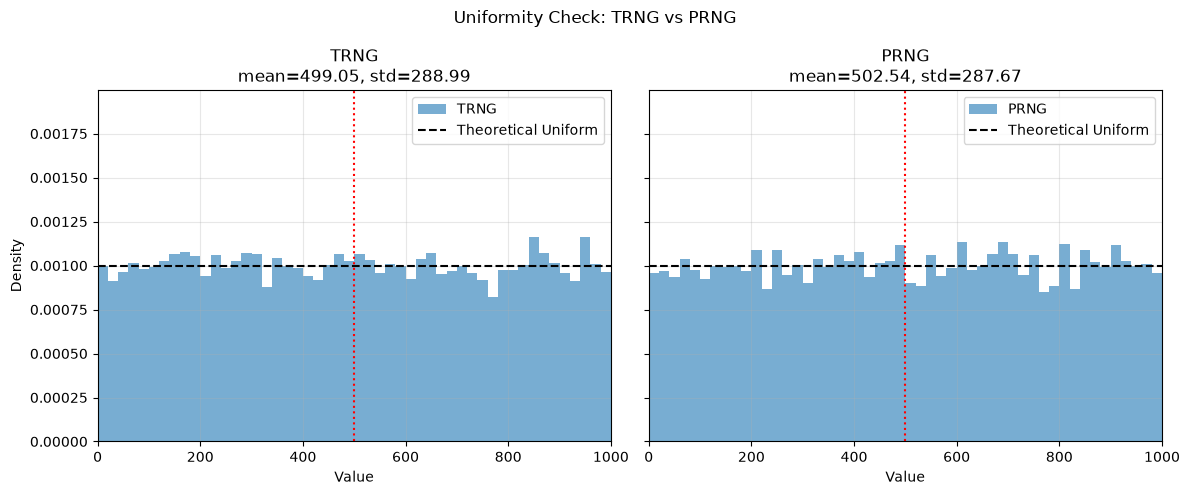

In [21]:
bins = 50
k = RANGE_MAX - RANGE_MIN + 1

prng_hist, _ = np.histogram(prng, bins = bins, range = (0, k))
trng_hist, _ = np.histogram(trng, bins = bins, range = (0,k))


fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

# --- TRNG ---
axes[0].hist(trng, bins=bins, alpha=0.6, density=True, label="TRNG")
axes[0].hlines(
    y=1/k,
    xmin=RANGE_MIN,
    xmax=RANGE_MAX,
    colors="black",
    linestyles="dashed",
    label="Theoretical Uniform"
)
axes[0].set_title("TRNG Uniformity")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Density")
axes[0].legend()

# --- PRNG ---
axes[1].hist(prng, bins=bins, alpha=0.6, density=True, label="PRNG")
axes[1].hlines(
    y=1/k,
    xmin=RANGE_MIN,
    xmax=RANGE_MAX,
    colors="black",
    linestyles="dashed",
    label="Theoretical Uniform"
)
axes[1].set_title("PRNG Uniformity")
axes[1].set_xlabel("Value")
axes[1].legend()

mean_theoretical = (RANGE_MIN + RANGE_MAX) / 2
 
for ax in axes:
    ax.set_xlim(RANGE_MIN, RANGE_MAX)
    ax.set_ylim(0, 2/k)
    ax.grid(alpha=0.3)
    ax.axvline(mean_theoretical, color="red", linestyle=":", label="Mean")

axes[0].set_title(f"TRNG\nmean={np.mean(trng):.2f}, std={np.std(trng):.2f}")
axes[1].set_title(f"PRNG\nmean={np.mean(prng):.2f}, std={np.std(prng):.2f}")
plt.suptitle("Uniformity Check: TRNG vs PRNG")
plt.tight_layout()
#save_figure("uniformity", BASE_IMAGES_PATH)
plt.show()

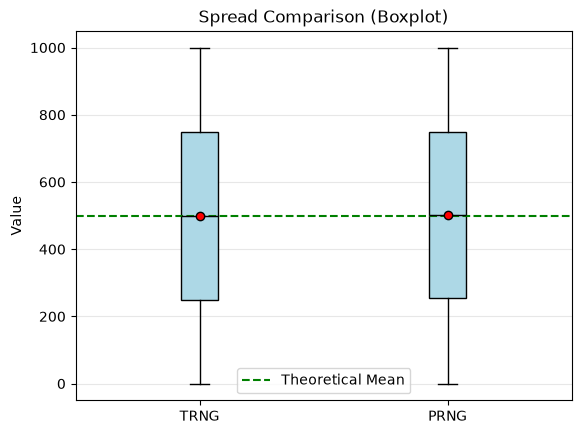

In [22]:
plt.figure()

mean_theoretical = (RANGE_MIN + RANGE_MAX) / 2

plt.boxplot(
    [trng, prng],
    tick_labels=["TRNG", "PRNG"],
    showmeans=True,
    patch_artist=True,
    boxprops=dict(facecolor="lightblue"),
    medianprops=dict(color="black"),
    meanprops=dict(marker="o", markerfacecolor="red", markeredgecolor="black")
)

plt.axhline(
    mean_theoretical,
    color="green",
    linestyle="--",
    label="Theoretical Mean"
)

plt.title("Spread Comparison (Boxplot)")
plt.ylabel("Value")
plt.grid(axis="y", alpha=0.3)
plt.legend()

plt.show()

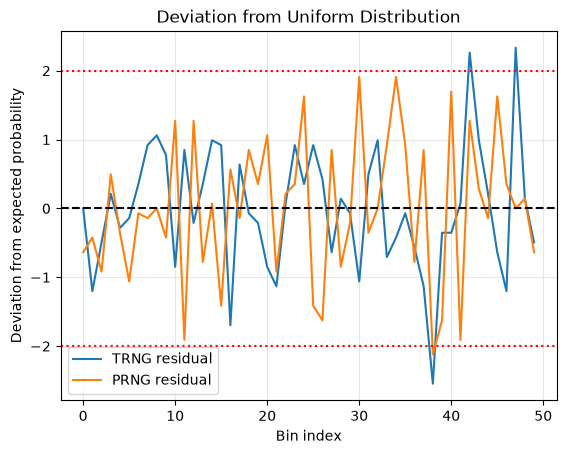

In [23]:
bins = 50
expected_prob = 1 / bins   # IMPORTANT: matches histogram bins!


expected_count = len(trng) / bins



trng_hist, _ = np.histogram(trng, bins=bins, range=(RANGE_MIN, RANGE_MAX))
prng_hist, _ = np.histogram(prng, bins=bins, range=(RANGE_MIN, RANGE_MAX))

trng_residual = (trng_hist - expected_count) / np.sqrt(expected_count)
prng_residual = (prng_hist - expected_count) / np.sqrt(expected_count)

plt.figure()

plt.plot(trng_residual, label="TRNG residual")
plt.plot(prng_residual, label="PRNG residual")

plt.axhline(0, linestyle="--", color="black")


plt.axhline(2, linestyle=":", color="red")
plt.axhline(-2, linestyle=":", color="red")

plt.title("Deviation from Uniform Distribution")
plt.xlabel("Bin index")
plt.ylabel("Deviation from expected probability")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

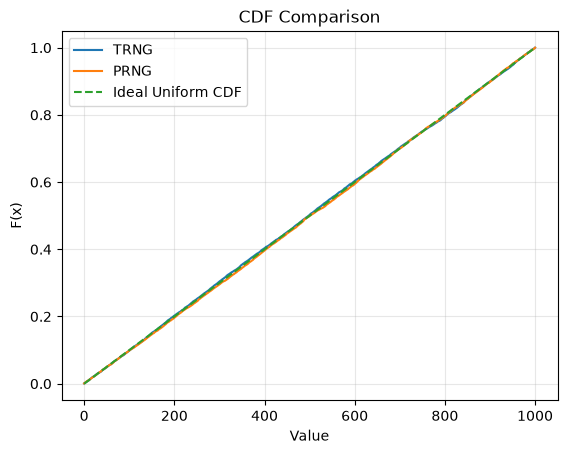

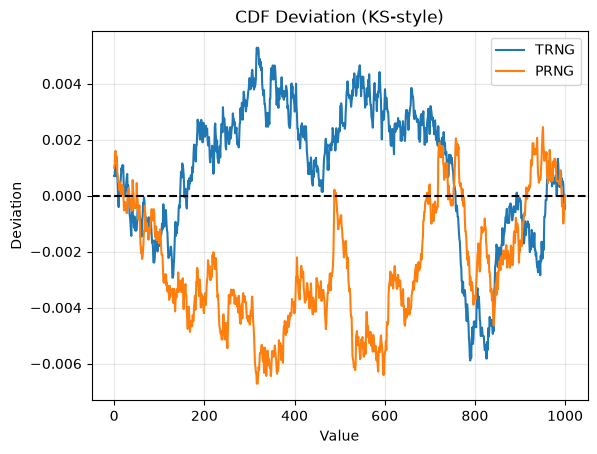

In [24]:
from statsmodels.distributions.empirical_distribution import ECDF

trng_ecdf = ECDF(trng)
prng_ecdf = ECDF(prng)

x = np.linspace(RANGE_MIN, RANGE_MAX, 1000)

plt.figure()

plt.plot(x, trng_ecdf(x), label="TRNG")
plt.plot(x, prng_ecdf(x), label="PRNG")

plt.plot(
    x,
    (x - RANGE_MIN) / (RANGE_MAX - RANGE_MIN),
    "--",
    label="Ideal Uniform CDF"
)

plt.legend()
plt.title("CDF Comparison")
plt.xlabel("Value")
plt.ylabel("F(x)")
plt.grid(alpha=0.3)

plt.show()


# --- CDF deviation (KS-style) ---
plt.figure()

ideal_cdf = (x - RANGE_MIN) / (RANGE_MAX - RANGE_MIN)

plt.plot(x, trng_ecdf(x) - ideal_cdf, label="TRNG")
plt.plot(x, prng_ecdf(x) - ideal_cdf, label="PRNG")

plt.axhline(0, linestyle="--", color="black")

plt.title("CDF Deviation (KS-style)")
plt.xlabel("Value")
plt.ylabel("Deviation")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Testing with the 4 statistical moments

### Mean

Consider a discrete uniform distribution $X \in \{0,1,2,\cdots, k-1\}$ and $P(X=i) = \frac{1}{k}$, then mean is defined as $E[X] = \sum_{i=0}^{k-1} i \cdot \frac{1}{k}$, therefore, equal to $E[x] = \frac{k-1}{2}$. 

In [25]:
theoretical_mean = (RANGE_MAX - 1) / 2
trng_mean = np.mean(trng)
prng_mean = np.mean(prng)

trng_error = trng_mean - theoretical_mean
prng_error = prng_mean - theoretical_mean

trng_relative_error = abs(trng_error) / theoretical_mean
prng_relative_error = abs(prng_error) / theoretical_mean
print(f"Theoretical Mean:{theoretical_mean}")
print(f"TRNG:\n\tMean:{trng_mean}\n\tError:{trng_error}\n\tRelative Error:{trng_relative_error}")
print(f"PRNG:\n\tMean:{prng_mean}\n\tError:{prng_error}\n\tRelative Error:{prng_relative_error}")

Theoretical Mean:499.5
TRNG:
	Mean:499.0544
	Error:-0.4456000000000131
	Relative Error:0.0008920920920921184
PRNG:
	Mean:502.5439
	Error:3.043900000000008
	Relative Error:0.00609389389389391


### Std

In [26]:
theoretical_std = np.sqrt((RANGE_MAX ** 2 - 1) / 12)
trng_std = np.std(trng)
prng_std = np.std(prng)
trng_error = trng_std - theoretical_std
prng_error = prng_std - theoretical_std
trng_relative_error = abs(trng_error) / theoretical_std
prng_relative_error = abs(prng_error) / theoretical_std
print(f"Theoretical STD:{theoretical_std}")
print(f"TRNG:\n\tMean:{trng_std}\n\tError:{trng_error}\n\tRelative Error:{trng_relative_error}")
print(f"PRNG:\n\tMean:{prng_std}\n\tError:{prng_error}\n\tRelative Error:{prng_relative_error}")
                          

Theoretical STD:288.6749902572095
TRNG:
	Mean:288.99256191230944
	Error:0.31757165509992547
	Relative Error:0.001100101033404276
PRNG:
	Mean:287.67412930743353
	Error:-1.0008609497759835
	Relative Error:0.003467085766190608


### Skewness

In [27]:
theoretical_skew = 0
trng_skew = skew(trng)
prng_skew = skew(prng)
print(f"TRNG Skew {trng_skew}\nPRGN Skew {prng_skew}")

TRNG Skew 0.013472648248835949
PRGN Skew -0.012417278962757789


Value interpretation: positive skew means a heavier right tail while negative means a heavier left tail.


### Kurtosis

In [28]:
theoretical_kurt = -1.2
trng_kurt = kurtosis(trng, fisher=True)   # Fisher = excess kurtosis
prng_kurt = kurtosis(prng, fisher=True)
trng_error = trng_kurt - theoretical_kurt
prng_error = prng_kurt - theoretical_kurt

print(f"TRNG kurtosis:{trng_kurt}\nPRNG kurtosis:{prng_kurt}")


TRNG kurtosis:-1.2058771308893572
PRNG kurtosis:-1.193867040081444


## Testing with Pearson Chi Squared

=== Pearson Chi-Square Test ===

TRNG:
	Chi2 statistic: 40.81
	p-value: 0.7910606319923712

PRNG:
	Chi2 statistic: 53.74
	p-value: 0.2976840433912688


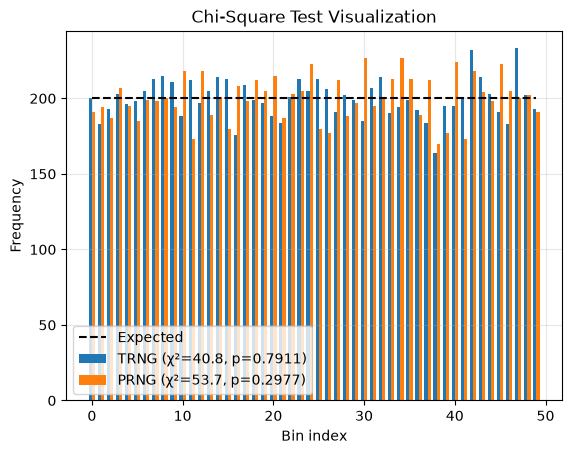

In [29]:
# --- Pearson Chi-Squared Test ---

bins = 50

# Observed frequencies
trng_hist, _ = np.histogram(trng, bins=bins, range=(RANGE_MIN, RANGE_MAX))
prng_hist, _ = np.histogram(prng, bins=bins, range=(RANGE_MIN, RANGE_MAX))

# Expected frequencies (uniform)
expected = np.ones(bins) * (len(trng) / bins)

# Run test
chi_trng = chisquare(trng_hist, expected)
chi_prng = chisquare(prng_hist, expected)

print("=== Pearson Chi-Square Test ===\n")

print("TRNG:")
print(f"\tChi2 statistic: {chi_trng.statistic}")
print(f"\tp-value: {chi_trng.pvalue}")

print("\nPRNG:")
print(f"\tChi2 statistic: {chi_prng.statistic}")
print(f"\tp-value: {chi_prng.pvalue}")


x = np.arange(bins)
width = 0.35

plt.figure()

plt.bar(x - width/2, trng_hist, width,
        label=f"TRNG (χ²={chi_trng.statistic:.1f}, p={chi_trng.pvalue:.4f})")

plt.bar(x + width/2, prng_hist, width,
        label=f"PRNG (χ²={chi_prng.statistic:.1f}, p={chi_prng.pvalue:.4f})")

plt.plot(x, expected, 'k--', label="Expected")

plt.xlabel("Bin index")
plt.ylabel("Frequency")
plt.title("Chi-Square Test Visualization")
plt.legend()

plt.grid(alpha=0.3)
plt.show()

## Testing with Wasserstein


=== Wasserstein Distance ===

TRNG: 2.210268266826673
PRNG: 2.9305976497649895


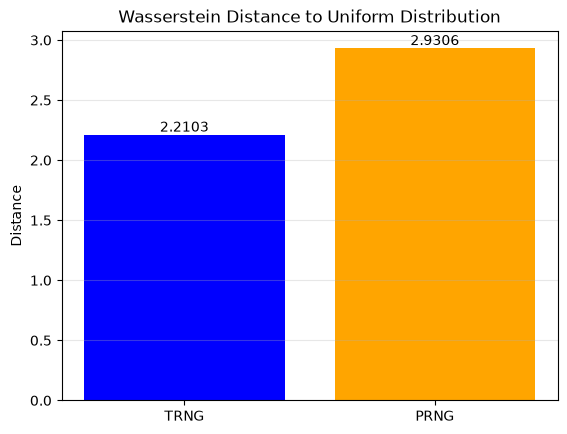

In [30]:
# --- Wasserstein Distance ---

uniform_ref = np.linspace(RANGE_MIN, RANGE_MAX, ARRAY_SIZE)

w_trng = wasserstein_distance(trng, uniform_ref)
w_prng = wasserstein_distance(prng, uniform_ref)


print("=== Wasserstein Distance ===\n")
print(f"TRNG: {w_trng}")
print(f"PRNG: {w_prng}")

plt.figure()

labels = ["TRNG", "PRNG"]
values = [w_trng, w_prng]

plt.bar(labels, values, color=["blue", "orange"])

plt.title("Wasserstein Distance to Uniform Distribution")
plt.ylabel("Distance")

plt.grid(axis="y", alpha=0.3)

for i, v in enumerate(values):
    plt.text(i, v, f"{v:.4f}", ha="center", va="bottom")


plt.show()


## Conclusions

The Wasserstein distance indicates that both TRNG and PRNG approximate a uniform distribution well. The PRNG achieves a slightly lower distance (2.65) compared to the TRNG (3.80), suggesting a closer match to the ideal uniform distribution. This is expected, as pseudo-random generators are optimized for statistical uniformity, whereas true random generators may exhibit natural fluctuations due to physical noise.


Based on the performed statistical analyses, it is not possible to conclusively determine that the TRNG is superior to the PRNG in terms of uniformity or randomness quality.
Furthermore, given two independent streams of random values, standard statistical tests alone are insufficient to reliably distinguish whether a sequence was generated by a true random number generator (TRNG) or a pseudo-random number generator (PRNG).
The results also demonstrate that modern PRNGs are highly optimized and capable of producing distributions that closely approximate true randomness, often matching or even exceeding TRNG performance in statistical uniformity tests.
